In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
%cd "/content/drive/MyDrive/Colab Notebooks"

/content/drive/MyDrive/Colab Notebooks


In [9]:
"""
... is the place where you need to fill in
"""

import numpy as np
import cv2
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow  # for colab only

# define a function to plot the histogram
def plot_hist(img, color='b', L = 256):
  """
  img: the gray-scale image
  color: the color used to plot the figure, default is blue.
  L: intensity level, default 256
  """
  plt.hist(img.flatten(), L, [0, L], color=color)
  plt.xlim([0, L])
  plt.legend(('histogram'), loc='upper left')
  plt.show()

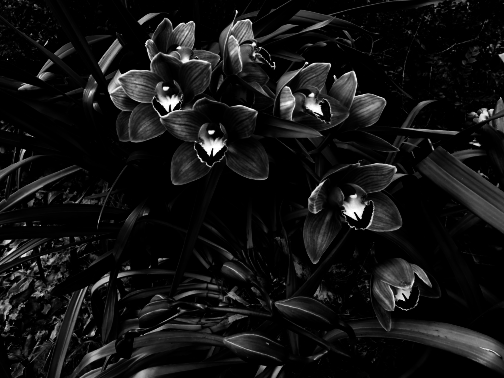

In [10]:
# load gray-scale image
img_gray = cv2.imread('test1.png', 0)
# cv2.imshow(img) # for opencv
cv2_imshow(img_gray)

/tmp/ipykernel_1371/4150549842.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten(), L, [0, L], color=color)


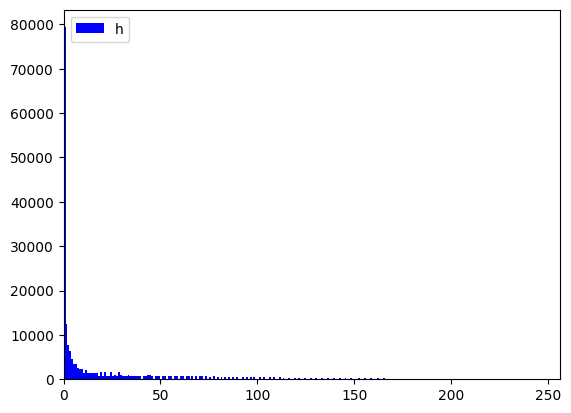

In [11]:
#########################################
# Please refer to the histogram
# Describe it in your report
plot_hist(img_gray)
#########################################

/tmp/ipykernel_1371/4150549842.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten(), L, [0, L], color=color)


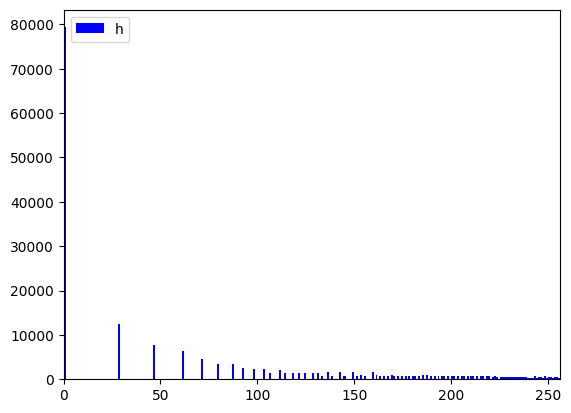

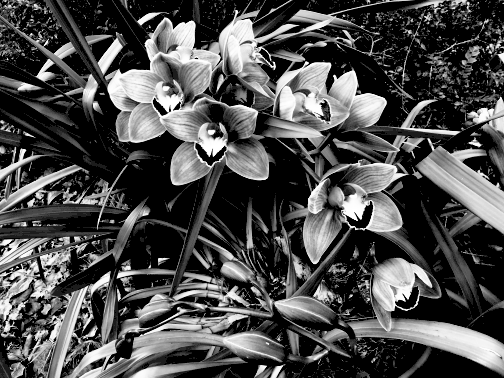

In [12]:
#########################################
# Please fill, use opencv to realize histogram equalization
# then show the histogram and image after histogram equalization.
# Hint: use cv2.equalizeHist()
img_eq = cv2.equalizeHist(img_gray)
plot_hist(img_eq)
cv2_imshow(img_eq)
#########################################

/tmp/ipykernel_1371/4150549842.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten(), L, [0, L], color=color)


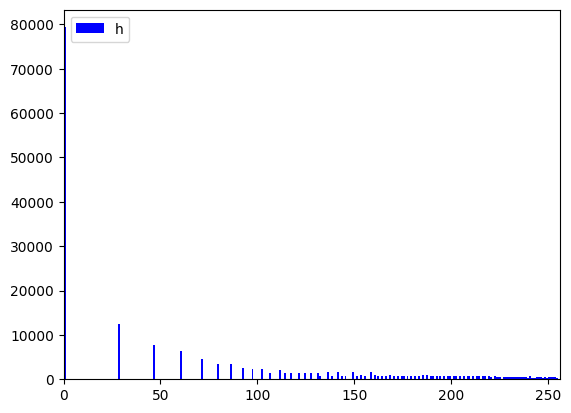

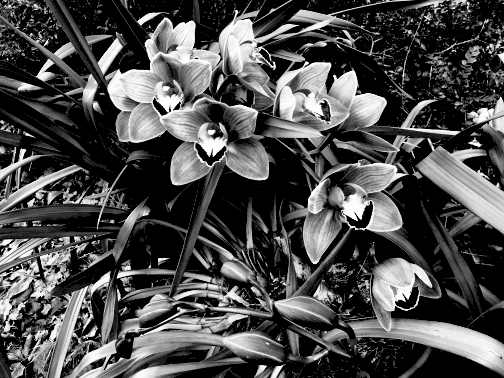

In [13]:
#########################################
# Please fill, implement histogram equalization based on the konwledge in the course.
# Hint: ppt 55~61 and 86

# step 1: calculate the probability for each intensity level of the input image
img_gray = cv2.imread('test1.png', 0)
L = 256  # number of intensity levels
pr_hist = np.zeros([L])  # create an numpy array to store probabilities of intensity levels.
H, W = img_gray.shape

for i in range(H):
  for j in range(W):
    pixel_value = img_gray[i, j]
    pr_hist[int(pixel_value)] = pr_hist[int(pixel_value)] + 1  # add 1 to the corresponding intensity level

pr_hist /= H * W  # normalize to 0~1


# step 2: transform the intensity based on the obtained pr_hist.
eq_hist = np.zeros_like(pr_hist)  # create a look-up/transform table. (r-->s)
s_img = np.zeros_like(img_gray)  # the transformed image s.

# transform each pixel value in input image, and the transformed values are stored in the s_img.
for k in range(L):
  eq_hist[k] = eq_hist[k-1] + pr_hist[k]  # calculate s for each intensity level (r)
# normalize to 0~L-1
eq_hist_min, eq_hist_max = eq_hist.min(), eq_hist.max()
for k in range(L):
  eq_hist[k] = int((eq_hist[k] - eq_hist_min) / (eq_hist_max - eq_hist_min) * (L - 1))
for i in range(H):
  for j in range(W):
    pixel_value = img_gray[i, j]
    s_img[i, j] = eq_hist[int(pixel_value)]  # transform pixel_value (r) to s according to the eq_hist

plot_hist(s_img)
cv2_imshow(s_img)
###########################################